In [12]:
from dotenv import load_dotenv
load_dotenv()
from langgraph.graph import StateGraph, START,END
from typing import TypedDict

In [15]:
class BatsmanState(TypedDict):
    runs:int
    balls:int
    fours:int
    sixes:int

    sr:float
    bpb:float
    boundary_percent:float
    summary:str

def calculate_sr(state:BatsmanState):
    sr = (state['runs']/state['balls'])*100
    state['sr'] = sr
    return {'sr':sr}

def calculate_bpb(state:BatsmanState):
    bpb = (state['fours']+state['sixes'])/state['balls']
    state['bpb'] = bpb
    return {'bpb':bpb}

def boundary_percent(state:BatsmanState):
    percent = ((state['fours']+state['sixes'])/state['balls'])*100
    state['boundary_percent'] = percent
    return {'boundary_percent':percent}


def summary(state:BatsmanState):
    summary = f"""
    Strike Rate - {state['sr']}\n
    Balls per boundary - {state['bpb']}\n
    Boundary percent - {state['boundary_percent']}
    """
    state['summary'] = summary
    return {'summary':summary}

In [16]:
graph = StateGraph(BatsmanState)

graph.add_node("calculate_sr",calculate_sr)
graph.add_node("calculate_bpb",calculate_bpb)
graph.add_node("boundary_percent",boundary_percent)
graph.add_node("summary",summary)

graph.add_edge(START,"calculate_sr")
graph.add_edge(START,"calculate_bpb")
graph.add_edge(START,"boundary_percent")


graph.add_edge("calculate_sr","summary")
graph.add_edge("calculate_bpb","summary")
graph.add_edge("boundary_percent","summary")\

graph.add_edge("summary",END)

workflow= graph.compile()

initial_state = {'runs':100,'balls':50,'fours':6,'sixes':4}

final_state = workflow.invoke(initial_state)
print(final_state)

{'runs': 100, 'balls': 50, 'fours': 6, 'sixes': 4, 'sr': 200.0, 'bpb': 0.2, 'boundary_percent': 20.0, 'summary': '\n    Strike Rate - 200.0\n\n    Balls per boundary - 0.2\n\n    Boundary percent - 20.0\n    '}


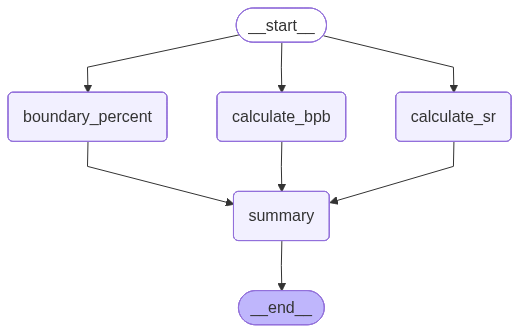

In [17]:
workflow